# Olist Marketplace End-to-End Analytics & Data Engineering Pipeline

Welcome to the production notebook for the Olist E-Commerce optimization project. This notebook serves as the initial ingestion, diagnostic, and algorithmic engine of the data pipeline.

---
**Project Context:** This notebook forms the exploratory and data engineering backbone of the Olist Marketplace Analysis. For the comprehensive enterprise-grade documentation, full architectural blueprints, business logic breakdown, and final Power BI dashboard outcomes, please refer to the primary [**Project README.md**](../README.md).

---

---

## Table of Contents

* ### [Phase 1: Data Wrangling & Preprocessing](#phase-1-data-wrangling--preprocessing)
  **Objective:** Transform raw, fragmented relational CSV files from the Olist marketplace ecosystem into a highly integrated, cleaned, and algorithmically enriched dataset. This phase focuses on establishing data hygiene, handling statistical anomalies, and extracting behavioral intelligence via unsupervised machine learning before repository ingestion.

* **Data Inputs:** Raw Olist datasets (`Orders`, `Order Items`, `Sellers`, `Products`, `Customers`, `Reviews`, `Geolocation`).
* **Engineering Deliverables:** * Strict schema validation (data type corrections, constraint checking).
 * Imputation pipelines for handling missing structural and operational attributes.
 * Statistical correlation analysis (Spearman Rank) mapping logistics against satisfaction scores.
 * An engineered behavioral merchant dimension (`dim_sellers_rfm`) driven by K-Means++ Clustering.
    * [1.1 Consolidation](#11-consolidation)
    * [1.2 Duplicate Assessment & Removal](#12-duplicate-assessment--removal)
    * [1.3 Missing Values Exploration](#13-missing-values-exploration)
    * [1.4 Handling Missing Values](#14-handling-missing-values)
    * [1.5 Checking and Fixing Datatypes for each Table](#15-checking-and-fixing-datatypes-for-each-table)
    * [1.6 Geolocation Dataset](#16-geolocation-dataset)
    * [1.7 Delivery Metrics & Correlation Analysis](#17-delivery-metrics--correlation-analysis)
    * [1.8 Vendor RFM Calculation & K-Means Clustering](#18-vendor-rfm-calculation--k-means-clustering)
    * [1.9 RFM Segmentation Mapping](#19-rfm-segmentation-mapping)
* ### [Phase 2: Database Ingestion & Bulk Upload](#phase-2-database-ingestion-bulk-upload)
* **Data Inputs:** Enriched and cleaned Pandas DataFrames from Phase 1.
* **Engineering Deliverables:**
 * Automated database connection engine utilizing SQLAlchemy and PyODBC.
 * Production-ready Bulk Staging Layer schema creation inside SQL Server.
 * Strict metadata mapping to ensure data integrity and datatype compliance across database tables.
 * A production-ready physical Star Schema layout mapped out via SQL Server Diagramming.

    * [2.1 SQL Server Bulk Export Pipeline](#21-sql-server-bulk-export-pipeline)
    * [2.2 Database Management & DW Modeling](#22-database-management--dw-modeling)
    * [2.3 Final Production Star Schema (SSMS ER Diagram)](#23-final-production-star-schema-ssms-er-diagram)

* ### [Phase 3: BI Reporting & Value Creation (Power BI Semantic Layer)](#phase-4-semantic-layer-architecture--bi-reporting-power-bi-preview)

  **Objective:** Map the physical data warehouse structures into a high-performance Semantic Layer inside Power BI Desktop. This final phase leverages advanced relational context filtering, complex analytical modeling (DAX), and human-centric design patterns to convert rows and columns into predictive executive dashboards.

* **Data Inputs:** Optimized analytical SQL Server database views and tables.
* **Engineering Deliverables:**
    * Advanced Semantic Layer data modeling utilizing role-playing spatial dimensions to eliminate relationship loops.
    * Calculated metrics engine housing 17 complex operational, financial, and time-intelligence DAX measures.
    * An enterprise-grade, dark-themed UI/UX multi-page executive report complete with interactive drillthrough audit functionalities.

---

# Data Dictionary & Marketplace Background Information

## 1. Background Information
Olist is the leading e-commerce department store solution in Brazil, operating as a SaaS platform that seamlessly connects thousands of small local merchants to major national digital retail channels. This relational dataset captures the entire end-to-end transaction lifecycle of approximately 100,000 real, anonymized consumer orders placed between 2016 and 2018.

> **Data Architecture Note:** For an exhaustive field-level schema breakdown, SQL/Power BI data types, and granular operational business logic for all 9 relational tables, please refer to the standalone [`Olist_documentation.md`](./Olist_documentation.md) manual.

---
# Olist datasets :
* olist_customers_dataset.csv
* olist_geolocation_dataset.csv
* olist_order_items_dataset.csv
* olist_order_payments_dataset.csv
* olist_order_reviews_dataset.csv
* olist_orders_dataset.csv
* olist_products_dataset.csv
* olist_sellers_dataset.csv
* product_category_name_translation.csv

## 1. Environment Setup & Library Imports
Initialize the project environment and import core libraries

In [39]:
import os
import pandas as pd
import urllib
from sqlalchemy import create_engine
import sqlalchemy

import scipy.stats as stats
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

##  Data Ingestion
Load the raw Olist relational datasets from local storage into Pandas DataFrames for preprocessing.

In [7]:
customers = pd.read_csv(r'E:\Olist Dataset\Data\olist_customers_dataset.csv')
orders = pd.read_csv(r'E:\Olist Dataset\Data\olist_orders_dataset.csv')
order_items = pd.read_csv(r'E:\Olist Dataset\Data\olist_order_items_dataset.csv')
payments = pd.read_csv(r'E:\Olist Dataset\Data\olist_order_payments_dataset.csv')
products = pd.read_csv(r'E:\Olist Dataset\Data\olist_products_dataset.csv')
translations = pd.read_csv(r'E:\Olist Dataset\Data\product_category_name_translation.csv')
reviews = pd.read_csv(r'E:\Olist Dataset\Data\olist_order_reviews_dataset.csv')
sellers = pd.read_csv(r'E:\Olist Dataset\Data\olist_sellers_dataset.csv')

# Phase 1: Data Wrangling & Preprocessing

## Consolidation
Map dataset names to their respective DataFrames in a unified dictionary to streamline iterative operations and automated cleaning checks.

In [8]:
# Create a dictionary to map table names to their respective DataFrames
datasets = {
    'Customers': customers,
    'Orders': orders,
    'Order Items': order_items,
    'Payments': payments,
    'Products': products,
    'Translations': translations,
    'Reviews': reviews,
    'Sellers': sellers
}


## Duplicate Assessment & Removal
Iterate through all datasets to detect duplicate rows. Automatically remove identified duplicates in-place to ensure data uniqueness.

In [9]:
# Check for duplicate rows in each dataset
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name} Table has {duplicate_count} duplicate rows.")
    
    # If duplicates exist, drop them in-place
    if duplicate_count > 0:
        df.drop_duplicates(inplace=True)
        print(f"--> Fixed: Removed duplicates from {name} Table.")

Customers Table has 0 duplicate rows.
Orders Table has 0 duplicate rows.
Order Items Table has 0 duplicate rows.
Payments Table has 0 duplicate rows.
Products Table has 0 duplicate rows.
Translations Table has 0 duplicate rows.
Reviews Table has 0 duplicate rows.
Sellers Table has 0 duplicate rows.


> **Perfect!** All datasets are verified and contain **0 duplicate rows**. No further cleaning is required for data uniqueness.

## Missing Values Exploration
Scan all datasets to identify columns containing missing or null values. This assessment establishes the baseline for handling missing data across the relational schema.

In [10]:
# Loop through the dictionary and print .info() for each DataFrame
for name, df in datasets.items():
    null_counts = df.isnull().sum()
    # Filter to show only columns that have at least 1 null value
    missing_columns = null_counts[null_counts > 0]
    
    print(f"==================== {name.upper()} MISSING VALUES ====================")
    if not missing_columns.empty:
        print(missing_columns)
    else:
        print("No missing values found in this table.")
    print("\n" + "_"*60 + "\n")

==================== CUSTOMERS MISSING VALUES ====================
No missing values found in this table.

____________________________________________________________

==================== ORDERS MISSING VALUES ====================
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

____________________________________________________________

==================== ORDER ITEMS MISSING VALUES ====================
No missing values found in this table.

____________________________________________________________

==================== PAYMENTS MISSING VALUES ====================
No missing values found in this table.

____________________________________________________________

==================== PRODUCTS MISSING VALUES ====================
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
pr

> ### Missing Data Insights
> * **Clean Tables:** `Customers`, `Order Items`, `Payments`, `Translations`, and `Sellers` have **0** missing values.
> * **Orders Table:** Contains missing timestamps related to order fulfillment (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`).
> * **Products Table:** Missing metadata for 610 products and dimensions for 2 products.
> * **Reviews Table:** High volume of missing values in text fields (`review_comment_title`, `review_comment_message`), which is expected as comments are optional.

## Handling Missing Values: 



## Orders Table
### Decision: Retain Missing Timestamps as `NULL`
Missing values identified in fulfillment timestamps (`order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date`) will intentionally be left as **`NULL`**.

**Business Justification:**
* **Data Integrity:** Missing timestamps align with specific order statuses (e.g., `canceled` or `processing`), where the event naturally did not occur.
* **Downstream Analytics:** Imputing dummy dates would skew shipping duration, logistics performance, and delivery delay metrics during subsequent analysis and dashboarding (e.g., in SQL or Power BI).
* **Compatibility:** Modern BI tools and SQL databases natively handle `NULL` values in datetime fields without breaking computations.

## Products Table

### Decision: Fill Missing Values
* **Why?** We cannot delete these products because they are linked to real sales and revenue.
* **Action:** 
  * Fill missing `product_category_name` with **`'unknown'`**.
  * Fill missing numbers (weights, sizes, photo quantities) with **`0`** to keep data types consistent.


**Note:** For a detailed business analysis and logistics justification regarding why we used `0` instead of the Mean/Median, please check the **README.md** file.

In [11]:
# Fill categorical column with 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Fill numerical product specs with 0
num_product_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 
                    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_product_cols:
    products[col] = products[col].fillna(0)

# Verify that there are absolutely no missing values left in the entire products DataFrame
print("Total missing values in Products table:", products.isnull().sum().sum())


Total missing values in Products table: 0


#### Perfect no more NaNs in products table 
---

## Reviews Table

### Decision: Fill Missing Review Text
* **Why?** Customers rated the orders using stars (1 to 5) but chose not to write a title or a message. It is normal and we must keep the ratings.
* **Action:** 
  * Fill missing `review_comment_title` with **`'No Title'`**.
  * Fill missing `review_comment_message` with **`'No Message'`**.

In [12]:
# Fill text columns with standard placeholder text
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No Title')
# Corrected typo from 'lenght' to standard English naming conventions in comments if needed, but keeping actual column name
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No Message')

# Verify that there are no missing values left in the review comment columns
print("Missing values in comment titles:", reviews['review_comment_title'].isnull().sum())
print("Missing values in comment messages:", reviews['review_comment_message'].isnull().sum())

Missing values in comment titles: 0
Missing values in comment messages: 0


---

# Cheacking and fixing Datatypes for each Table 

### orders Table:

In [13]:
# Check current data types for Orders table
print(orders.dtypes)

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


### Observation: Incorrect Date Formats
* **Issue:** All timestamp columns (e.g., `order_purchase_timestamp`, `order_approved_at`) are currently stored as text (`object`).
* **Impact:** We cannot perform time-based analysis or duration calculations in this format.

---


## Converting Timestamps to Datetime
* **Action:** Convert the identified date columns from text (`object`) to proper `datetime` format.
* **Handling Errors:** Used `errors='coerce'` to safely handle any formatting issues by setting faulty dates to `NaT` (Not a Time).

In [14]:
# List of columns that need to be converted to datetime
orders_date_cols = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

# Convert columns to datetime
for col in orders_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Verify the changes for this table specifically
print("\n--- Verified Data Types for Orders Table ---")
print(orders[orders_date_cols].dtypes)


--- Verified Data Types for Orders Table ---
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [15]:
# Print the data types of the orders table after conversion
print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## Reviews Table

In [16]:
# Check current data types for Reviews table
print(reviews.dtypes)

review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


## Reviews Table

### Observation: Incorrect Date Formats
* **Issue:** The date columns `review_creation_date` and `review_answer_timestamp` are currently stored as text (`object`).
* **Impact:** These need to be converted to actual dates to track review response times accurately.
---

## Converting Reviews Timestamps to Datetime
* **Action:** Convert `review_creation_date` and `review_answer_timestamp` from text to proper `datetime` format.
* **Goal:** Enable future time-based tracking, such as calculating the response time for customer reviews.

In [17]:
# List of columns that need to be converted to datetime in Reviews
reviews_date_cols = ['review_creation_date', 'review_answer_timestamp']

# Convert columns to datetime with error handling
for col in reviews_date_cols:
    reviews[col] = pd.to_datetime(reviews[col], errors='coerce')

# Verify the changes for this table specifically
print("\n--- Verified Data Types for Reviews Table ---")
print(reviews[reviews_date_cols].dtypes)


--- Verified Data Types for Reviews Table ---
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


In [18]:
print(reviews.dtypes)

review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


## Products Table 

In [19]:
# Check current data types for Products table
print(products.dtypes)

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


## Products Table

### Observation: Inconsistent Numeric Types
* **Issue:** Columns like `product_name_lenght`, `product_description_lenght`, and `product_photos_qty` are stored as decimals (`float64`).
* **Impact:** These represent counts and lengths, so they logically should be whole numbers (`int64`) for clean representation.
---

### Fixing the datatypes 

In [20]:
# List of columns to convert from float to int
cols_to_int = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']

# Convert using astype()
for col in cols_to_int:
    products[col] = products[col].astype('int64')

# Verify the changes
print("--- Verified Data Types for Products Table ---")
print(products[cols_to_int].dtypes)

--- Verified Data Types for Products Table ---
product_name_lenght           int64
product_description_lenght    int64
product_photos_qty            int64
dtype: object


In [21]:
print(products.dtypes)

product_id                     object
product_category_name          object
product_name_lenght             int64
product_description_lenght      int64
product_photos_qty              int64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


### All the columns dtypes are now fixed
---

## Data Type Assessment: Remaining Tables
* **Action:** Scan the data types for the remaining datasets (`Customers`, `Order Items`, `Payments`, `Sellers`, and `Translations`).
* **Goal:** Verify if there are any remaining formatting inconsistencies before finalizing the data type adjustment phase.

In [22]:
remaining_datasets = {
    'Customers': customers,
    'Order Items': order_items,
    'Payments': payments,
    'Sellers': sellers,
    'Translations': translations
}

for name, df in remaining_datasets.items():
    print(f"--- {name} Table Data Types ---")
    print(df.dtypes)
    print("\n" + "_"*40 + "\n")

--- Customers Table Data Types ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

________________________________________

--- Order Items Table Data Types ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

________________________________________

--- Payments Table Data Types ---
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

________________________________________

--- Sellers Table Data Types ---
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype:

## Observation from Remaining Tables
* **Issue:** Inside the `Order Items` table, the column `shipping_limit_date` is currently stored as text (`object`).
* **Conclusion:** All other columns across these datasets have correct data types (IDs and text as `object`, values as `float64`/`int64`) and look ready.
---

## Converting Shipping Limit Date to Datetime

In [23]:
# Convert shipping_limit_date to datetime in Order Items table
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

# Verify the fix
print("Order Items Table - Shipping Limit Date Type:")
print(order_items['shipping_limit_date'].dtypes)

Order Items Table - Shipping Limit Date Type:
datetime64[ns]


In [24]:
print(order_items.dtypes)

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


## For Geolocation Dataset
The `olist_geolocation_dataset.csv` is an extremely heavy file containing **over 1 Million rows** of spatial coordinates ($Latitude$ and $Longitude$). 
* Loading this dataset initially with the other tables would unnecessarily drain system memory (RAM).
* **Data Redundancy:** Upon deep inspection, the dataset contains massive duplication where the exact same `zip_code_prefix` is repeated dozens of times with micro-differences in coordinates (just a few meters apart in the same street).
* Uploading 1M+ rows to SQL Server and feeding them into Power BI would severely degrade query performance and slow down dashboard rendering, without adding any real business value.

For furthar Details Check the **README.md** file.

---

## Geolocation Data Compression
* **Problem:** The raw geolocation dataset is extremely heavy and contains redundant rows for the same zip codes.
* **Action:** * Group data by `zip_code_prefix` and calculate the average latitude and longitude (`mean`) to compress the file size.
  * Rename columns to clean, standardized names (`zip_code_prefix`, `lat`, `lng`, `city`, `state`).
  * Upload the final compressed table directly to SQL Server as `stg_geolocation`.

In [25]:
# 1. Load the heavy geolocation file
geo = pd.read_csv(r'E:\Olist Dataset\Data\olist_geolocation_dataset.csv')

# 2. Aggregate coordinates by zip_code_prefix to remove redundant rows
# We take the mean (average) lat and lng for each unique zip code
print("Aggregating coordinates to reduce file size...")
geo_cleaned = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',  # Keep the first city name associated
    'geolocation_state': 'first'  # Keep the first state name associated
}).reset_index()

# Rename columns to make them clean and standard
geo_cleaned.columns = ['zip_code_prefix', 'lat', 'lng', 'city', 'state']

print(f"Original rows: {len(geo)} | Cleaned/Compressed rows: {len(geo_cleaned)}")

Aggregating coordinates to reduce file size...
Original rows: 1000163 | Cleaned/Compressed rows: 19015


> ### Compression Summary:
> * **Original Rows:** 1,000,163
> * **Cleaned/Compressed Rows:** 19,015
> * **Reduction Rate:** **~98%** decrease in data volume, ensuring faster queries and optimized storage in SQL Server.

# Phase 2: Database Ingestion & Bulk Upload
## SQL Server Bulk Export Pipeline

* **Connection Setup:** Establish a secure connection to the local SQL Server database (`Olist_DB`) using SQLAlchemy and PyODBC.
* **Staging Mapping:** Map all 9 cleaned and optimized DataFrames to their respective SQL staging table names (`stg_`).
* **Execution:** Run a loop to bulk-upload all datasets using `chunksize=5000` to optimize memory management and ensure a stable data transfer.

## WARNING: Run this cell ONCE only to prevent overwriting the SQL schema constraints. However SQL Server will rise an error if you tried to rerun it.

In [29]:
# # 1. Connection Parameters
# server = 'localhost'  # Use '.' or 'localhost' for default instance
# database = 'Olist_DB'
# driver = 'ODBC Driver 17 for SQL Server'

# # 2. Create the SQLAlchemy Database Engine
# params = urllib.parse.quote_plus(f"DRIVER={{{driver}}};SERVER={server};DATABASE={database};Trusted_Connection=yes;")
# engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# # 3. Consolidate all 9 cleaned DataFrames into a pipeline dictionary
# final_tables = {
#     'stg_customers': customers,
#     'stg_orders': orders,
#     'stg_order_items': order_items,
#     'stg_payments': payments,
#     'stg_products': products,
#     'stg_translations': translations,
#     'stg_reviews': reviews,
#     'stg_sellers': sellers,
#     'stg_geolocation': geo_cleaned  # Optimized and compressed spatial dataset
# }

# # 4. Execute the Bulk Upload Pipeline
# print("Starting the Final Bulk Upload Pipeline to SQL Server...\n")

# for table_name, df in final_tables.items():
#     print(f"Uploading {table_name} ({len(df)} rows)...")
#     # Using chunksize for memory management and smoother transfer
#     df.to_sql(name=table_name, con=engine, if_exists='replace', index=False, chunksize=5000)
#     print(f"{table_name} uploaded successfully!\n")

# print("=" * 50)
# print("SUCCESS: All 9 tables are now live inside Olist_DB!")

> ### Pipeline Executed Successfully!
> All **9 tables** have been fully cleaned, optimized, and successfully migrated into **`Olist_DB`**. 

---

## Next Step: Database Management & DW Modeling
The Python data cleaning and staging phase is now **complete**. 

**Moving to SSMS (SQL Server Management Studio) to:**
* Verify data schemas and row counts.
* Define primary keys, foreign keys, and establish table relationships.
* Build the final Data Warehouse dimensional model (Fact & Dimension tables).
* Build optimized SQL database views (v_dim_, v_fact_) to establish a clean abstraction layer for direct, high-performance Power BI ingestion.

---
---
### Final Production Star Schema (SSMS ER Diagram)

The pipeline now successfully transitions from data staging to formal relational modeling. Below is the **Full Final Schema** reverse-engineered and generated directly inside Microsoft SQL Server Management Studio (SSMS). 

This architecture enforces full referential integrity across transactional facts and dimensional context, including our machine-learning-derived behavioral dimensions.

>  **Deep-Dive Documentation & Production Code:** 
> For an exhaustive architectural breakdown, detailed engineering challenge resolutions, and full T-SQL execution scripts, please refer to the dedicated [SQL Warehouse Modeling Documentation](./sql/SQL_WAREHOUSE_MODELING.md).

![SQL Server Star Schema Diagram](../sql/Star_schema_ER_digram.png)



After successfully deploying the core Data Warehouse (Fact & Dimension tables) inside SSMS and establishing the baseline Star Schema, the business required a deeper look into operational efficiency and seller behavior. 

While SQL is highly optimized for structured data storage, relationships, and aggregations, **Python** provides the advanced statistical libraries (`pandas`, `numpy`, `seaborn`, `scipy`) required to run complex correlation matrices, feature engineering, and behavioral modeling at scale.

---

### Objective
We initiate a deeper analytical loop to uncover hidden patterns within fulfillment operations and marketplace dynamics:

1. **Fulfillment & Delivery Metrics Engineering:** * Extracting and calculating precise operational timeframes such as *Estimated vs. Actual Delivery Times*, *Seller Shipping Delays*, and *Carrier Freight Performance*.
   
2. **Statistical Correlation Analysis:**
   * Running a comprehensive statistical correlation matrix to understand how shipping speed, freight costs, and logistical friction directly impact product review scores and repeat customer behavior.

3. **Strategic Foundation for Segmentation:**
   * The insights derived from these correlation matrices will serve as the mathematical foundation for our next major milestone: **Advanced Seller Segmentation (RFM Clustering using Machine Learning)**.

---

## Delivery Metrics & Correlation Analysis
* **Action:** Merge `Orders`, `Order Items`, and `Reviews` datasets to calculate the actual shipping duration (`delivery_days`).
* **Goal:** Compute a Spearman rank correlation matrix to explore the relationships between delivery time, shipping costs (`freight_value`), product price, and final customer review scores.

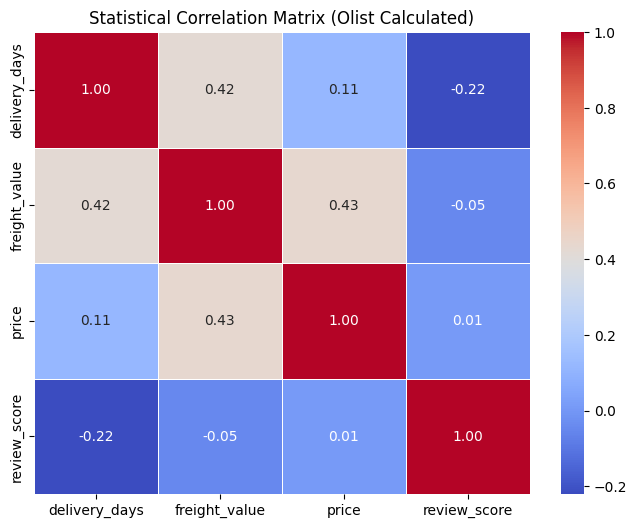

In [31]:
# 1. Merge datasets to bring orders, logistics, and reviews together
df_merged = datasets['Orders'].merge(datasets['Order Items'], on='order_id', how='inner')
df_merged = df_merged.merge(datasets['Reviews'], on='order_id', how='inner')

# 2. Ensure date columns are in proper datetime format
df_merged['order_delivered_customer_date'] = pd.to_datetime(df_merged['order_delivered_customer_date'])
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])

# 3. Calculate actual delivery duration in days
df_merged['delivery_days'] = (df_merged['order_delivered_customer_date'] - df_merged['order_purchase_timestamp']).dt.days

# 4. Define key metrics for correlation analysis
metrics = ['delivery_days', 'freight_value', 'price', 'review_score']

# 5. Drop nulls and compute Spearman correlation matrix
corr_data = df_merged[metrics].dropna()
corr_matrix = corr_data.corr(method='spearman')

# 6. Plot the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Statistical Correlation Matrix (Olist Calculated)')
plt.show()

### Statistical Insights from Correlation Matrix:
1. **Delivery Delay Impact:** A statistically significant negative correlation of **-0.22** between `delivery_days` and `review_score` confirms that longer delivery times directly degrade customer satisfaction.
2. **Freight & Price Dynamic:** A moderate positive correlation of **0.43** between `price` and `freight_value` indicates that higher-priced items usually incur higher shipping costs, likely due to item size/weight.
3. **Price Neutrality on Reviews:** The correlation between `price` and `review_score` is near zero (**0.01**), proving that product pricing does not influence customer ratings; satisfaction is strictly logistically driven.

---

---
## Vendor RFM Calculation & K-Means Clustering
* **RFM Generation:** Calculate **Recency** (days since last sale), **Frequency** (total unique orders), and **Monetary** (total sales revenue) for each individual seller.
* **Feature Scaling:** Apply `StandardScaler` to normalize the RFM metrics, ensuring equal weight distribution before training the algorithm.
* **Segmentation:** Execute **K-Means Clustering** to segment sellers into 4 distinct performance tiers based on their transactional behavior.

In [35]:
# 1. Merge datasets to link sales orders with their timestamps
seller_data = datasets['Order Items'].merge(datasets['Orders'], on='order_id', how='inner')
seller_data['order_purchase_timestamp'] = pd.to_datetime(seller_data['order_purchase_timestamp'])

# 2. Set the baseline date (latest order in the dataset) to calculate Recency
max_date = seller_data['order_purchase_timestamp'].max()

# 3. Aggregate data per seller to compute raw RFM metrics
rfm_sellers = seller_data.groupby('seller_id').agg({
    'order_purchase_timestamp': lambda x: (max_date - x.max()).days,
    'order_id': 'nunique',                                            
    'price': 'sum'                                                    
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
})

# 4. Standardize features to have a mean of 0 and variance of 1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_sellers)

# 5. Fit K-Means with 4 clusters and assign cluster labels to sellers
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm_sellers['Seller_Cluster'] = kmeans.fit_predict(rfm_scaled)

# 6. View the average RFM characteristics for each cluster
cluster_summary = rfm_sellers.groupby('Seller_Cluster').mean()
cluster_summary

,Recency,Frequency,Monetary
Seller_Cluster,,,
0,406.790761,5.922554,988.864497
1,59.590209,19.973708,2680.911097
2,11.210526,1032.052632,142751.670526
3,27.895522,238.656716,31622.894104


## RFM Segmentation & Vendor Insights

| Cluster | Business Segment | Recency (Avg) | Frequency (Avg) | Monetary (Total) | Status & Description |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Cluster 2** | **Champions / Mega Whales** | 11 Days | 1,032 Orders | 142,751 | Top-tier sellers with massive, non-stop sales volume. Highly active. |
| **Cluster 3** | **Core / Top Sellers** | 27 Days | 238 Orders | 31,622 | Stable, strong sellers. They form the backbone of daily platform trade. |
| **Cluster 1** | **New / Low-Value Active** | 59 Days | 19 Orders | 2,680 | New or low-scale sellers. Active but need marketing support to grow. |
| **Cluster 0** | **Hibernating / Lost Sellers** | 406 Days | 5 Orders | 988 | Inactive for over a year. Practically left the platform; lowest value. |

---

### Strategic Action Plan:
* **Champions (Cluster 2):** Provide premium support and exclusive loyalty rewards to retain them.
* **Core Sellers (Cluster 3):** Offer growth incentives to push them into the Champions tier.
* **New Active (Cluster 1):** Launch targeted incubation campaigns to boost their order frequency.
* **Lost Sellers (Cluster 0):** Low priority for marketing spend due to prolonged inactivity.

---
---
## RFM Segmentation Mapping
* **Action:** Map the identified numerical clusters to descriptive business segments (`Champions`, `Top Sellers`, etc.) for better readability.
* **Result:** Created a new column `Seller_Segment` to provide clear, actionable labels for every seller in the dataset.

In [36]:
# 1. Define a business-friendly dictionary to replace numerical cluster IDs
cluster_map = {
    2: 'Champions',
    3: 'Top Sellers',
    1: 'Active (Low-Value)',
    0: 'Lost/Hibernating'
}

# 2. Apply the mapping to assign descriptive labels to each seller
rfm_sellers['Seller_Segment'] = rfm_sellers['Seller_Cluster'].map(cluster_map)

# 3. Preview the final segmented dataset to verify results
rfm_sellers[['Recency', 'Frequency', 'Monetary', 'Seller_Segment']].head()

,Recency,Frequency,Monetary,Seller_Segment
seller_id,,,,
0015a82c2db000af6aaaf3ae2ecb0532,320,3,2685.00,Lost/Hibernating
001cca7ae9ae17fb1caed9dfb1094831,52,200,25080.03,Top Sellers
001e6ad469a905060d959994f1b41e4f,26,1,250.00,Active (Low-Value)
002100f778ceb8431b7a1020ff7ab48f,143,51,1234.50,Active (Low-Value)
003554e2dce176b5555353e4f3555ac8,262,1,120.00,Lost/Hibernating


### Final Segmentation Results Analysis:

1. **Lost/Hibernating (e.g., `0015a82c...`):** Extremely high recency (**320 days** since last order), indicating these sellers have effectively abandoned the platform despite historically generating moderate revenue (2,685.00).
2. **Top Sellers (e.g., `001cca7a...`):** Outstanding performance with very low recency (**52 days**), massive order frequency (**200 unique orders**), and strong financial volume (**25,080.03**). These are the core revenue drivers.
3. **Active Low-Value (e.g., `001e6ad4...`):** High recency/fresh activity (**26 days** since last order) but very low transactional volume (**1 order, 250.00**). These are either new onboarding sellers or niche low-scale accounts.

---
## Save the file in our database(sql server) to be used in the Power BI Report
## Again this code should be ran only once

In [40]:
# server = 'localhost'
# database = 'Olist_DB'
# driver = 'ODBC Driver 17 for SQL Server'

# # 2. Create the SQLAlchemy Database Engine
# params = urllib.parse.quote_plus(f"DRIVER={{{driver}}};SERVER={server};DATABASE={database};Trusted_Connection=yes;")
# engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")


# rfm_sellers.to_sql(
#     name='dim_sellers_rfm', 
#     con=engine, 
#     if_exists='replace', 
#     index=True, 
#     index_label='seller_id',
#     dtype={'seller_id': sqlalchemy.types.NVARCHAR(length=50)}
# )

303

---
## Phase 3: BI Reporting & Value Creation (Power BI Semantic Layer)

The data warehousing and structural T-SQL transformations inside SSMS are now fully deployed. The pipeline transitions into **Power BI Desktop** to architect the production semantic model, engineer advanced analytical metrics, and build the enterprise executive dashboard.

---
**Production BI Artifact Verification:** To inspect the compiled semantic data model, advanced DAX measures, and interactive UI/UX layout directly inside Power BI Desktop, navigate to the production file here: [`Olist.pbix`](../power_bi/Olist.pbix).

### Power BI Dimensional Model (Star Schema)
To maximize query performance and guarantee intuitive filter propagation paths, the optimized database views were imported to establish a strict, high-performance Star Schema layout. 

* **Role-Playing Dimensions (Spatial Optimization):** As noted in the database phase, the single geolocation storage table was logically split inside Power Query into two distinct role-playing dimension tables (`v_customers_dim_geolocation` and `v_sellers_dim_geolocation`) to prevent relationship ambiguity loops within the BI Engine.

Below is the finalized Power BI relationship network:

![Power BI Model View Architecture](../power_bi/Model_view_power_bi.png)

---

### Technical Deliverables & References

*  **Advanced DAX & Metrics Manual:** The complete inventory of all calculated enterprise indicators—including dynamic time-intelligence (YoY Growth, MTD), operational SLAs, and temporary context modifications via `CROSSFILTER`—is fully documented in the dedicated [`BI_DAX_MEASURES_MANUAL.md`](./BI_DAX_MEASURES_MANUAL.md) handbook.
* **Main Repository Handbook:** To review the full end-to-end architecture overview and high-level business findings, navigate back to the main [`README.md`](./README.md).